In [1]:
import xarray as xr
import pandas as pd
import dask
import glob
import os
import math

In [3]:
import numpy as np
import re

In [4]:
%run ~/analysis_tools/functions.py
%run ~/analysis_tools/mask_analysis.py


In [5]:

obs_ds = xr.open_dataset("/glade/work/qingyuany/cam7_re/obs.nc")


In [6]:
import matplotlib.pyplot as plt

In [27]:

obs_dict = {'RESTOM': 'toa_net_all_mon',
 'FSNT': 'fsnt',
 'FLNT': 'toa_lw_all_mon',
 'SWCF': 'toa_cre_sw_mon',
 'LWCF': 'toa_cre_lw_mon',
 'PRECT': 'PRECT',
 'TGCLDLWP': 'TGCLDLWP',
 'FSNTC': 'toa_sw_clr_t_mon',
 'FLUTC': 'toa_lw_clr_t_mon',
 'TMQ': 'PREH2O',
 'LHFLX': 'LHFLX'}





In [22]:
cli_nms = list(obs_dict.keys())



In [35]:
ppev1 = xr.open_dataset('/glade/work/qingyuany/cam7_re/v0/ppe_out.nc')
para = pd.read_csv('/glade/work/qingyuany/cam7_re/v0/para_consist.csv')

In [24]:
obs_dict.items()

dict_items([('RESTOM', 'toa_net_all_mon'), ('FSNT', 'fsnt'), ('FLNT', 'toa_lw_all_mon'), ('SWCF', 'toa_cre_sw_mon'), ('LWCF', 'toa_cre_lw_mon'), ('PRECT', 'PRECT'), ('TGCLDLWP', 'TGCLDLWP'), ('FSNTC', 'toa_sw_clr_t_mon'), ('FLUTC', 'toa_lw_clr_t_mon'), ('TMQ', 'PREH2O'), ('LHFLX', 'LHFLX')])

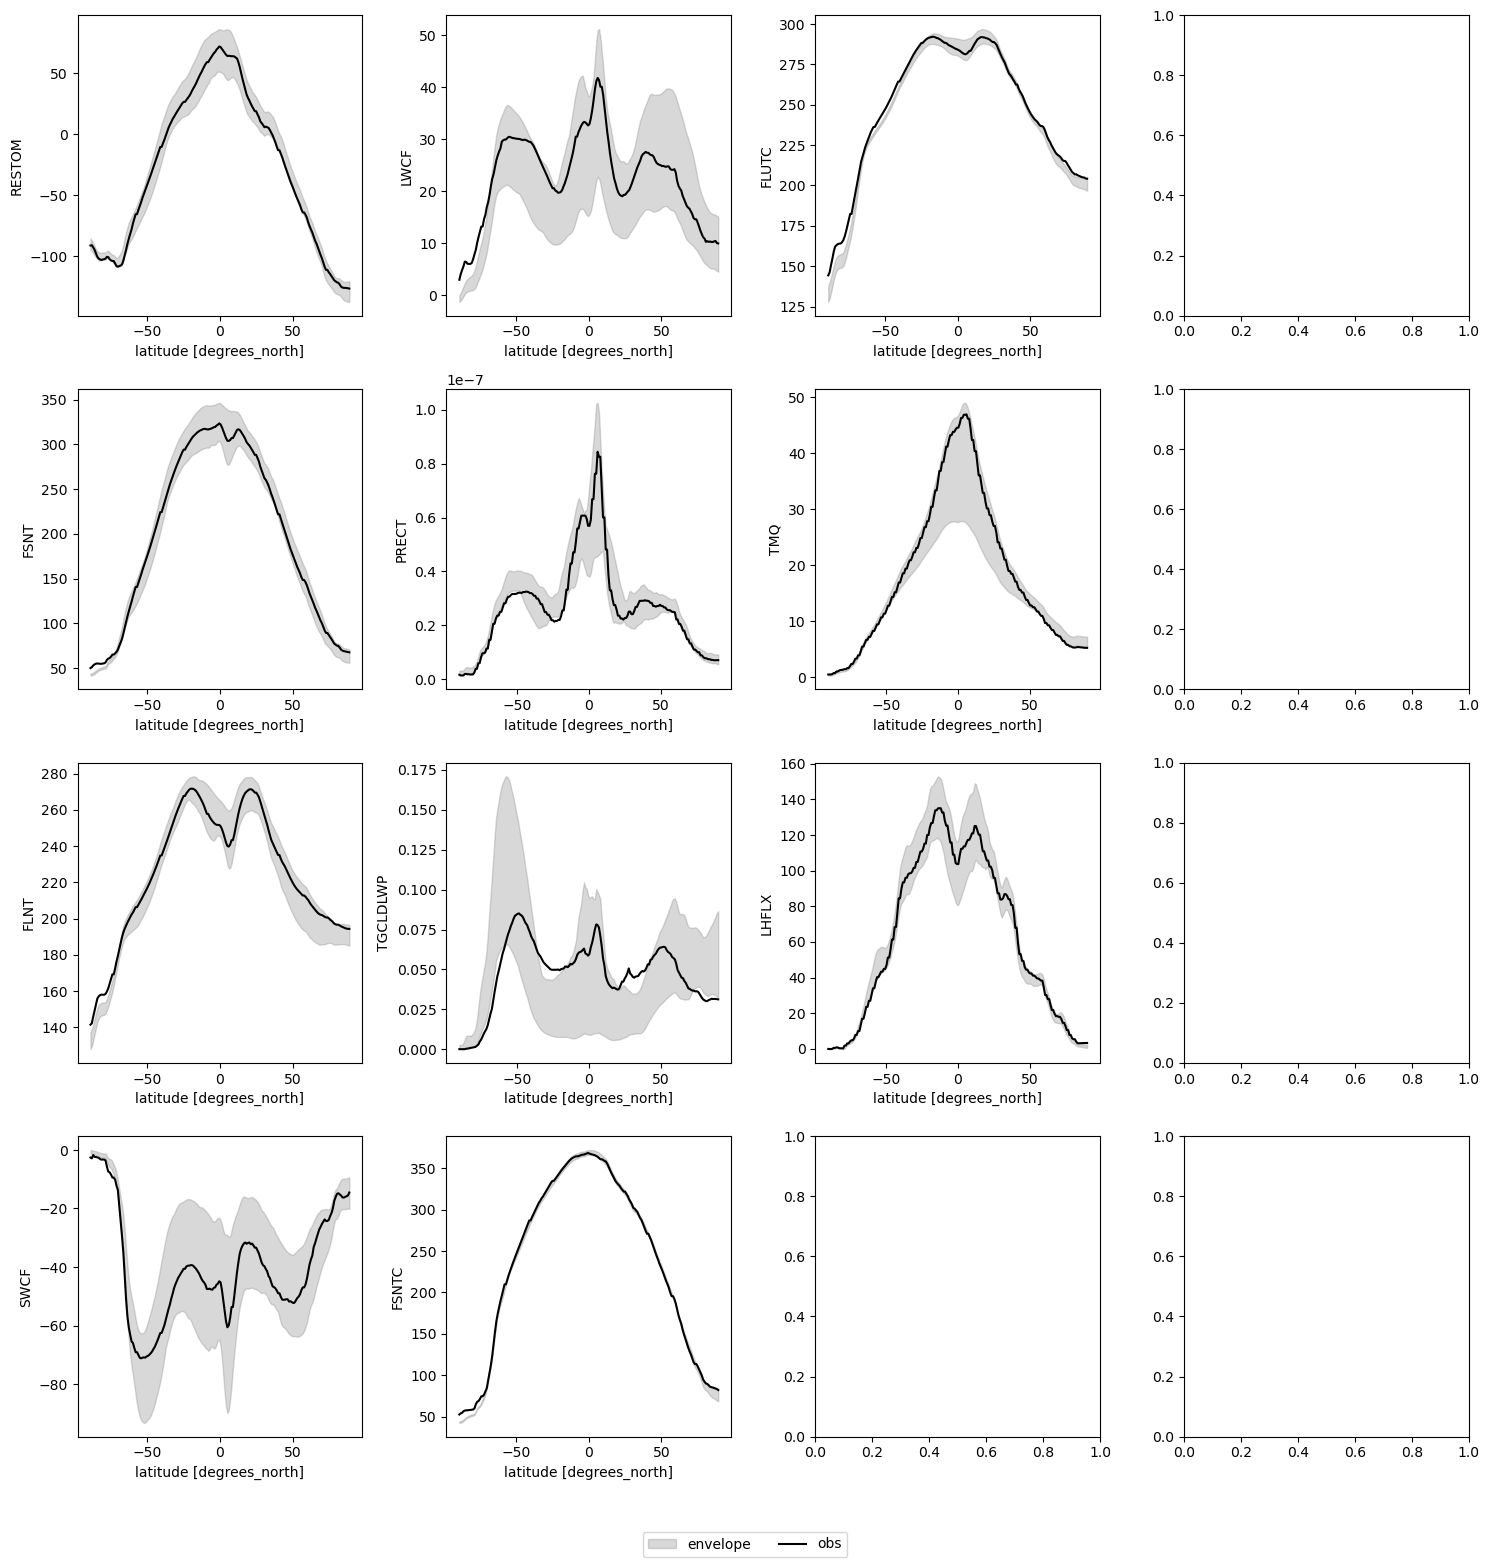

In [28]:
fig, axes = plt.subplots(4, 4, figsize = (15, 15))


for i, (cli_nm, obs_nm) in enumerate(obs_dict.items()):
    
    sim_temp_v1 = ppev1[cli_nm]
    
    
    sim_temp_v1 = sim_temp_v1.where(~obs_ds[obs_nm].isnull(), drop = True)
    
    ax = axes[i%4, math.floor(i/4)] 


    
    ax.fill_between(sim_temp_v1.lat, sim_temp_v1.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v1.mean(dim = "lon").min(dim = "ppe_ind"), 
                    color = "gray", label = "envelope", alpha = 0.3)
    
    
    obs_ds[obs_nm].mean(dim = "lon").plot(ax = ax, color = "black", label = "obs")
        
    ax.set_ylabel(cli_nm)

handles, labels = ax.get_legend_handles_labels()

# Create a single legend at the bottom
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4)

plt.tight_layout()

In [34]:
%run ../funs/plotting.py

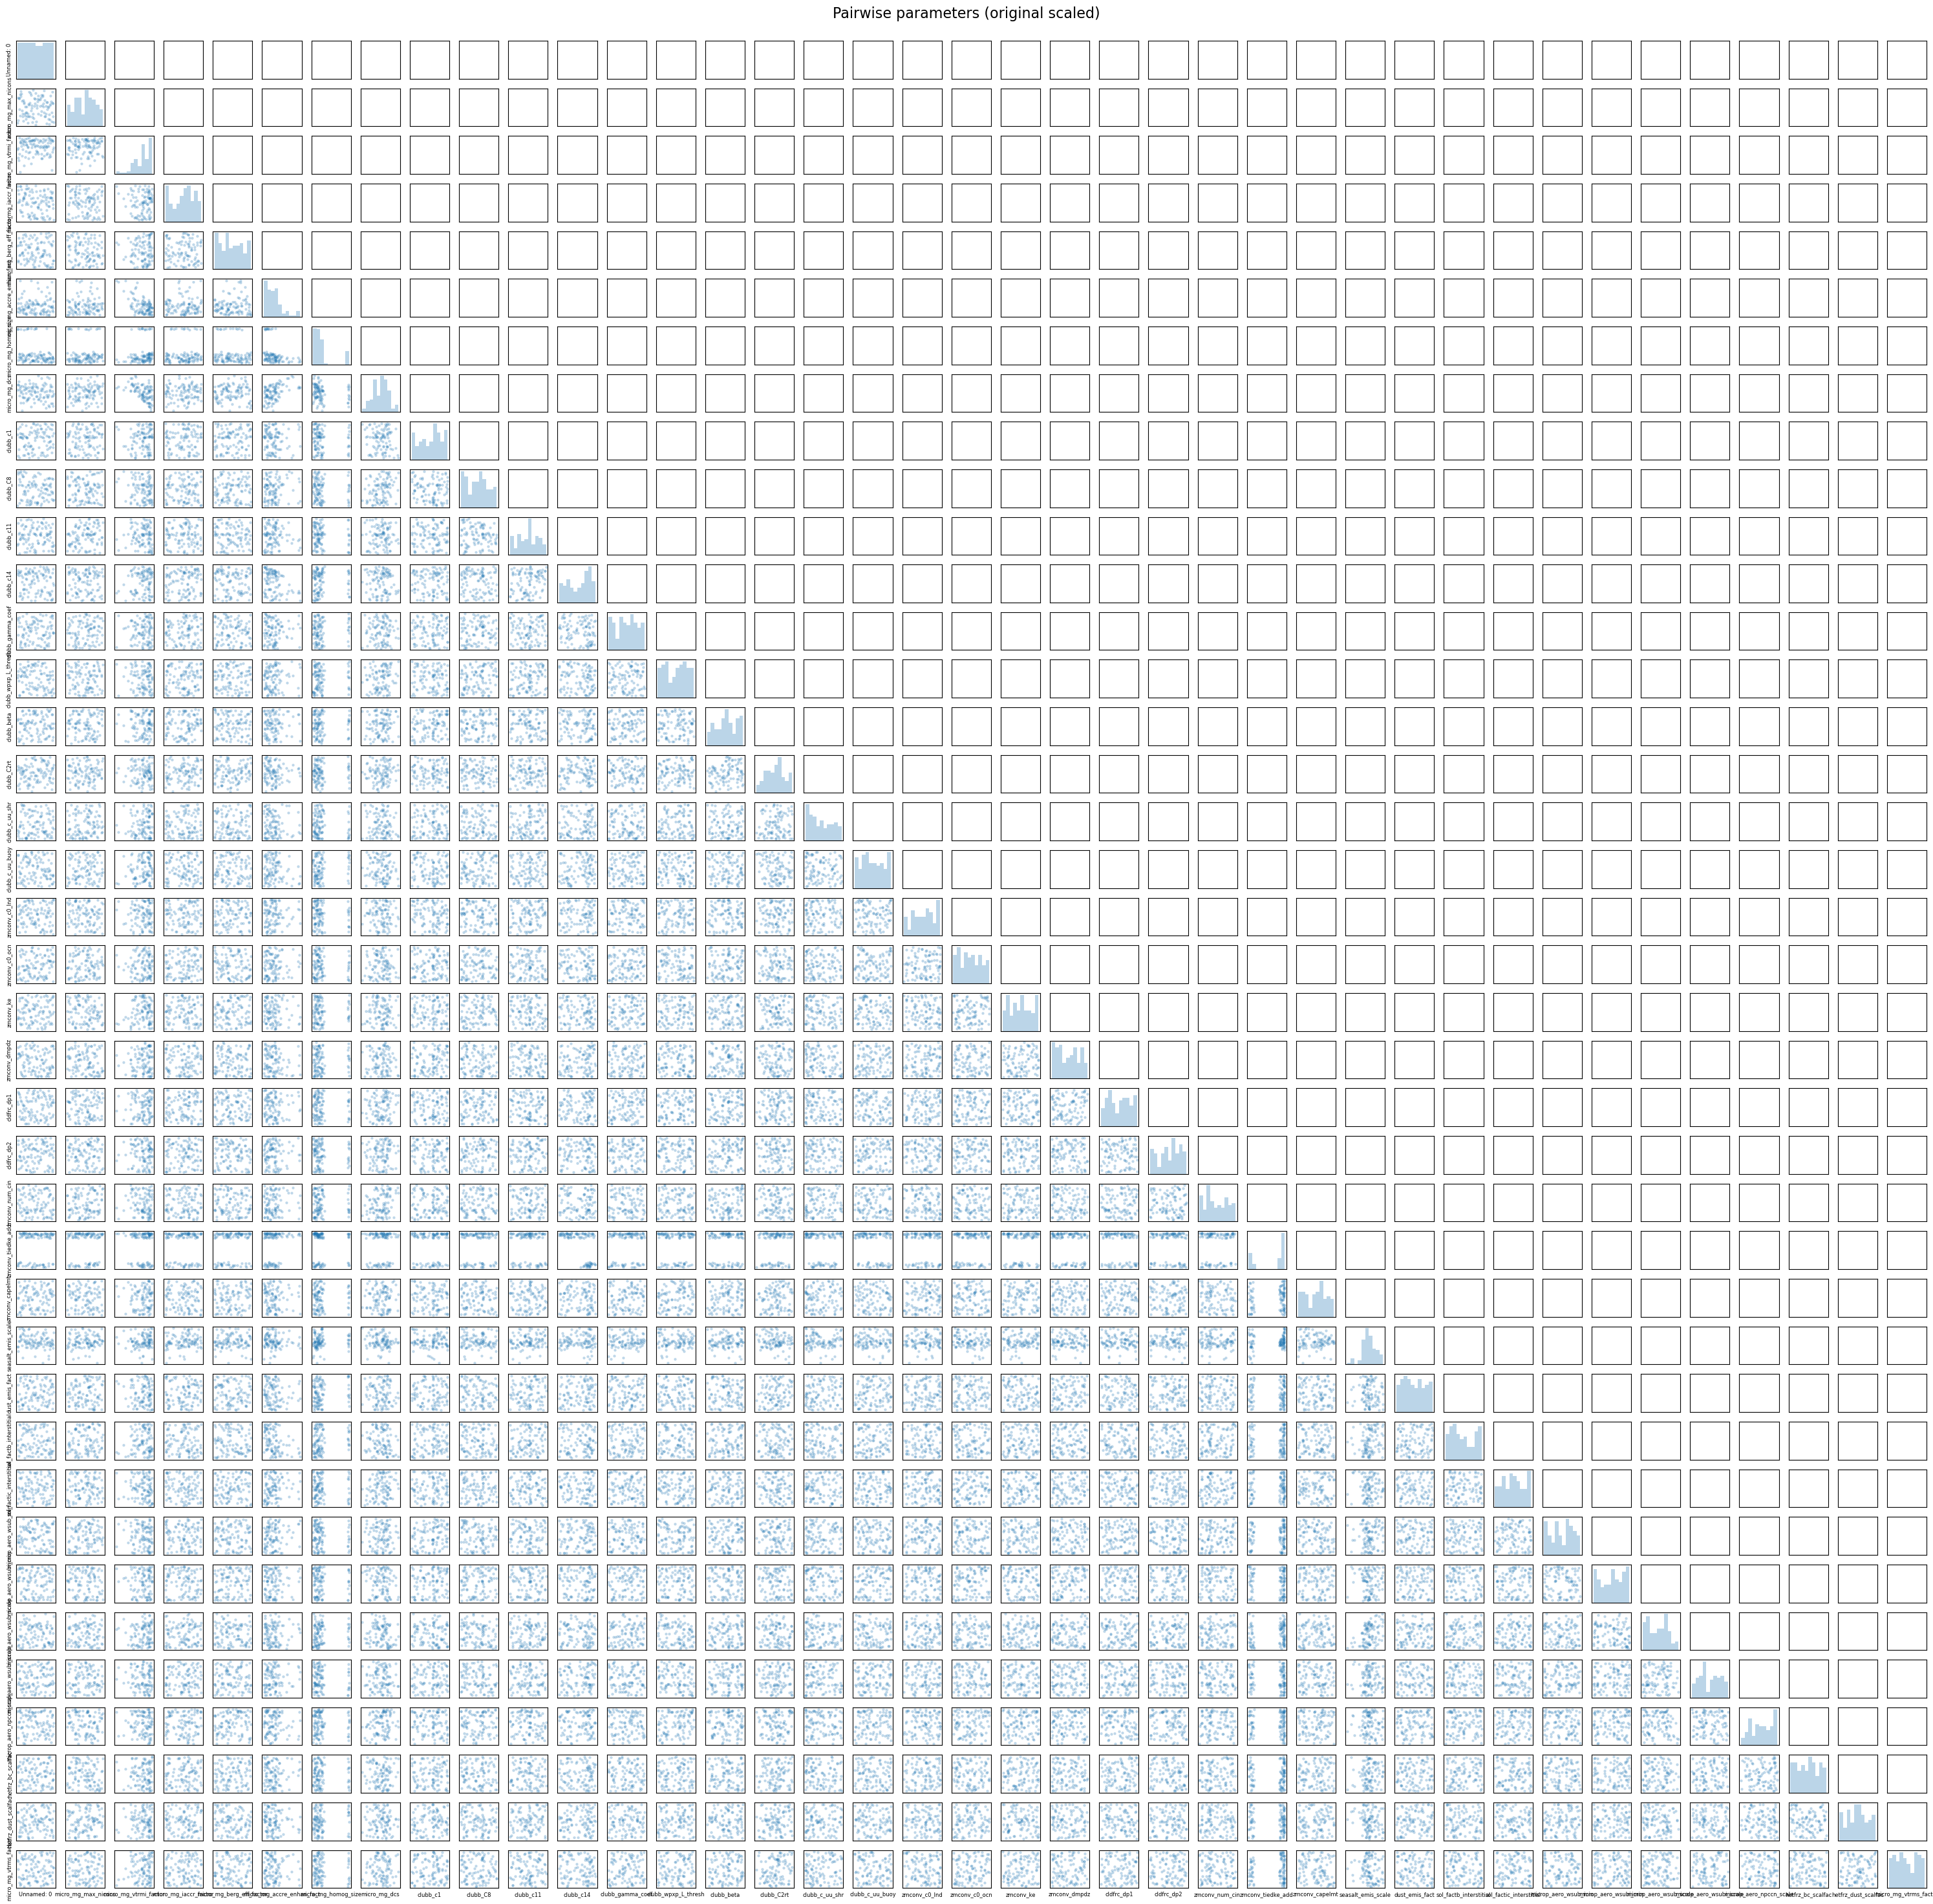

In [36]:
biplot_original_scale(para)